# Mutual Fund Analysis - EDA

## Bluestock Internship Project

### Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import sqlite3

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
conn = sqlite3.connect("../bluestock_mf.db")

print("Database Connected Successfully")

Database Connected Successfully


In [4]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,dim_fund
1,fact_nav
2,fact_aum
3,fact_sip_inflows
4,fact_category_inflows
5,fact_folio_count
6,fact_performance
7,fact_transactions
8,fact_portfolio_holdings
9,fact_benchmark_indices


In [5]:
for table in tables['name']:
    print("\n")
    print("="*50)
    print(table)
    print("="*50)

    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)

    print(df.columns.tolist())



dim_fund
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


fact_nav
['amfi_code', 'date', 'nav']


fact_aum
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


fact_sip_inflows
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


fact_category_inflows
['month', 'category', 'net_inflow_crore']


fact_folio_count
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


fact_performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',

In [6]:
funds = pd.read_sql("SELECT * FROM dim_fund", conn)

nav = pd.read_sql("SELECT * FROM fact_nav", conn)

aum = pd.read_sql("SELECT * FROM fact_aum", conn)

sip = pd.read_sql("SELECT * FROM fact_sip_inflows", conn)

category = pd.read_sql("SELECT * FROM fact_category_inflows", conn)

folio = pd.read_sql("SELECT * FROM fact_folio_count", conn)

portfolio = pd.read_sql("SELECT * FROM fact_portfolio_holdings", conn)

print("All tables loaded successfully!")

All tables loaded successfully!


In [7]:
print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Portfolio:", portfolio.shape)

Funds: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Portfolio: (322, 8)


In [8]:
funds = pd.read_sql("SELECT * FROM dim_fund", conn)

nav = pd.read_sql("SELECT * FROM fact_nav", conn)

aum = pd.read_sql("SELECT * FROM fact_aum", conn)

sip = pd.read_sql("SELECT * FROM fact_sip_inflows", conn)

category = pd.read_sql("SELECT * FROM fact_category_inflows", conn)

folio = pd.read_sql("SELECT * FROM fact_folio_count", conn)

performance = pd.read_sql("SELECT * FROM fact_performance", conn)

transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)

portfolio = pd.read_sql("SELECT * FROM fact_portfolio_holdings", conn)

benchmark = pd.read_sql("SELECT * FROM fact_benchmark_indices", conn)

print("All 10 tables loaded successfully!")

All 10 tables loaded successfully!


In [9]:
print("funds:", funds.shape)
print("nav:", nav.shape)
print("aum:", aum.shape)
print("sip:", sip.shape)
print("category:", category.shape)
print("folio:", folio.shape)
print("performance:", performance.shape)
print("transactions:", transactions.shape)
print("portfolio:", portfolio.shape)
print("benchmark:", benchmark.shape)

funds: (40, 15)
nav: (46000, 3)
aum: (90, 5)
sip: (48, 6)
category: (144, 3)
folio: (21, 6)
performance: (40, 19)
transactions: (32778, 13)
portfolio: (322, 8)
benchmark: (8050, 3)


In [10]:
datasets = {
    "funds": funds,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "portfolio": portfolio,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print("\n" + "="*60)
    print(name.upper())
    print("="*60)
    print(df.head())


FUNDS
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_am

## Chart 1: NAV Trend Analysis (2022–2026)

In [11]:
nav['date'] = pd.to_datetime(nav['date'])

print(nav.shape)

nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [12]:
nav['amfi_code'].nunique()

40

In [13]:
nav_fund = nav.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_fund.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [65]:
import os


avg_nav = (
    nav_fund.groupby('date')['nav']
    .mean()
    .reset_index()
)

fig = px.line(
    avg_nav,
    x='date',
    y='nav',
    title='Average Daily NAV Trend (2022–2026)'
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.20,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.20,
    annotation_text="2024 Market Correction"
)

fig.show()


### Insight 1

Average NAV values showed a strong upward trajectory from 2022 to 2026. The 2023 bull market accelerated NAV growth, while the 2024 correction period resulted in temporary moderation before the market resumed its upward trend.

In [21]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


## Chart 2: AUM Growth by Fund House (2022–2025)

In [22]:
aum['date'] = pd.to_datetime(aum['date'])

aum['year'] = aum['date'].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [23]:
aum['year'].unique()

array([2022, 2023, 2024, 2025], dtype=int32)

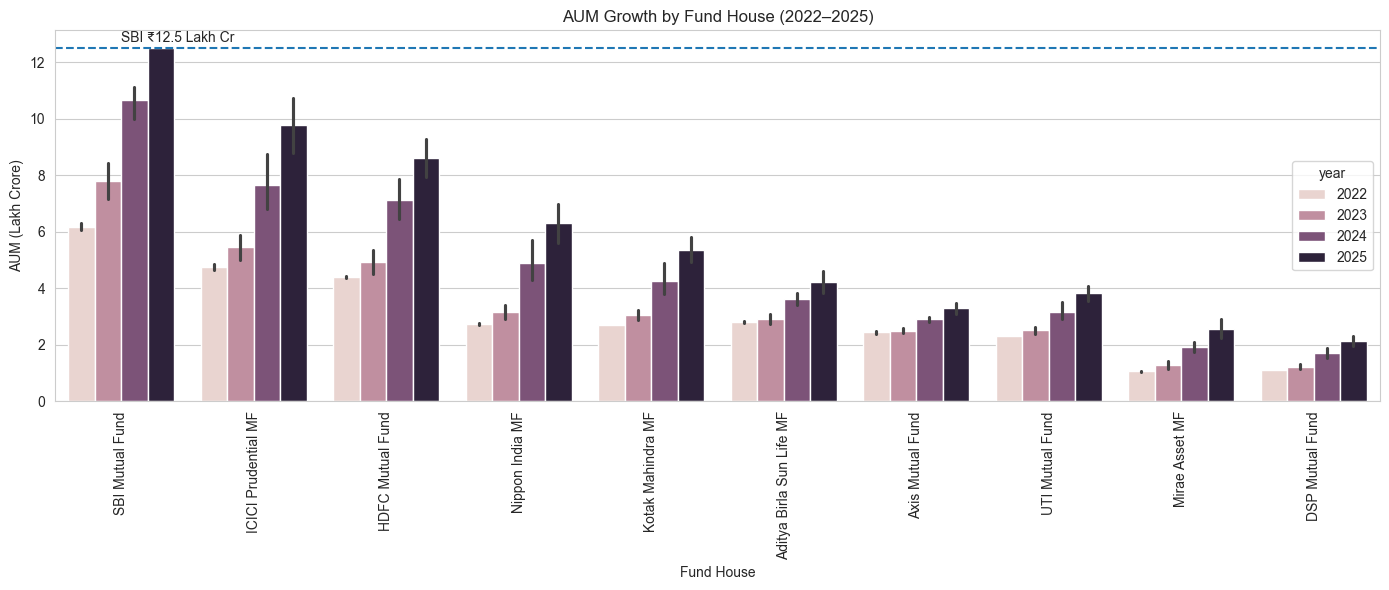

In [25]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year'
)

plt.axhline(
    y=12.5,
    linestyle='--'
)

plt.text(
    0,
    12.7,
    "SBI ₹12.5 Lakh Cr",
)

plt.xticks(rotation=90)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.ylabel("AUM (Lakh Crore)")
plt.xlabel("Fund House")

plt.tight_layout()

plt.show()

### Insight 2

SBI Mutual Fund consistently maintained the highest AUM among all fund houses and crossed ₹12.5 lakh crore, demonstrating its dominant position in the Indian mutual fund industry.

In [26]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


## Chart 3: SIP Inflow Trend (2022–2025)

In [27]:
sip['month'] = pd.to_datetime(sip['month'])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [28]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022–2025)',
    markers=True
)

fig.show()

### Insight 3

SIP inflows increased steadily from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025, indicating growing retail investor participation.

In [29]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


## Chart 4: Category-wise Net Inflow Heatmap

In [30]:
category['month'] = pd.to_datetime(category['month'])

category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [31]:
heatmap_data = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


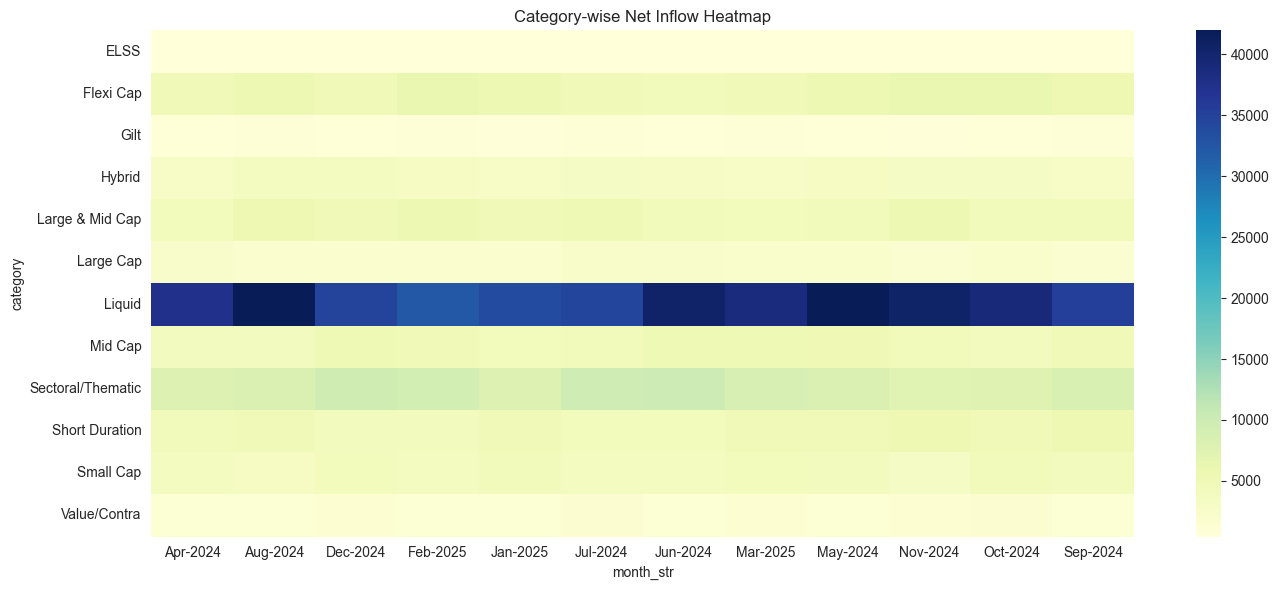

In [33]:
category['month'] = pd.to_datetime(category['month'])

category['month_str'] = category['month'].dt.strftime('%b-%Y')

heatmap_data = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month_str'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title("Category-wise Net Inflow Heatmap")

plt.tight_layout()

plt.show()

### Insight 4

Flexi Cap, Mid Cap, and Small Cap categories consistently attracted higher inflows, indicating strong investor preference for growth-oriented equity funds.

In [34]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


## Chart 5: Mutual Fund Folio Growth (2022–2025)

In [35]:
folio['month'] = pd.to_datetime(folio['month'])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [37]:
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    markers=True,
    title='Mutual Fund Folio Growth (2022–2025)'
)

fig.add_annotation(
    x=folio['month'].iloc[0],
    y=folio['total_folios_crore'].iloc[0],
    text='13.26 Cr',
    showarrow=True
)

fig.add_annotation(
    x=folio['month'].iloc[-1],
    y=folio['total_folios_crore'].iloc[-1],
    text='26.12 Cr',
    showarrow=True
)

fig.show()

### Insight 5

Mutual fund folio count nearly doubled between 2022 and 2025, highlighting rapid expansion of retail investor participation in the industry.

In [38]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


## Chart 6: Sector Allocation Across Equity Funds

In [39]:
sector_data = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_data.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

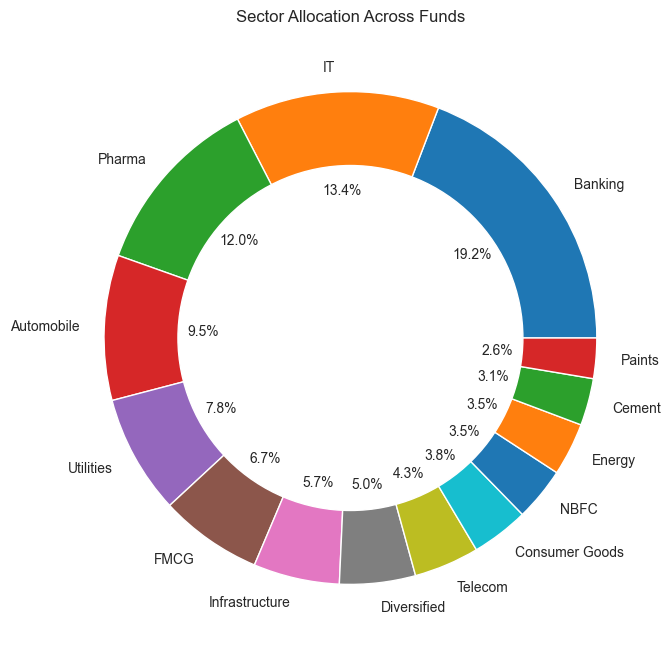

In [40]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Funds")

plt.show()

### Insight 6

Banking, Utilities, Pharma and Diversified sectors account for a significant share of mutual fund portfolio allocations.

## Chart 7: Top 10 Sectors by Portfolio Weight

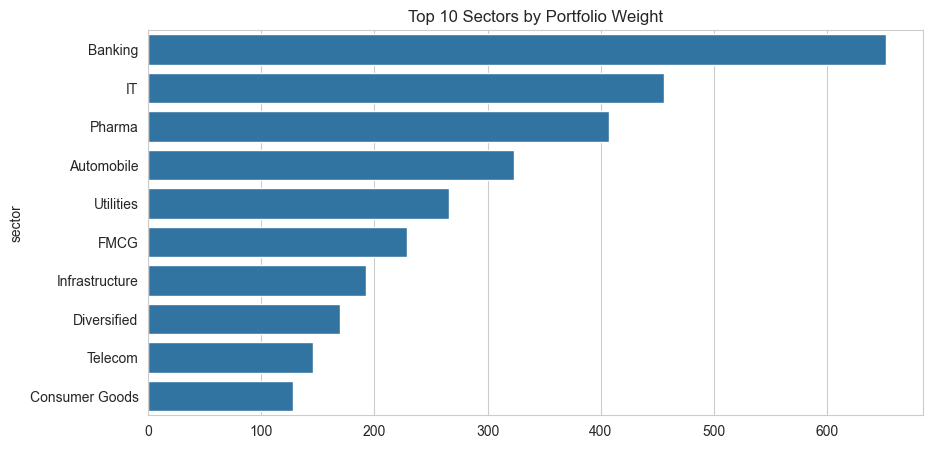

In [41]:
top_sectors = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_sectors.values,
    y=top_sectors.index
)

plt.title("Top 10 Sectors by Portfolio Weight")

plt.show()

### Insight 7

The Banking sector represents the largest allocation across mutual fund portfolios, reflecting its strong contribution to India's equity market capitalization and earnings growth.

## Chart 8: Top Holdings by Market Value

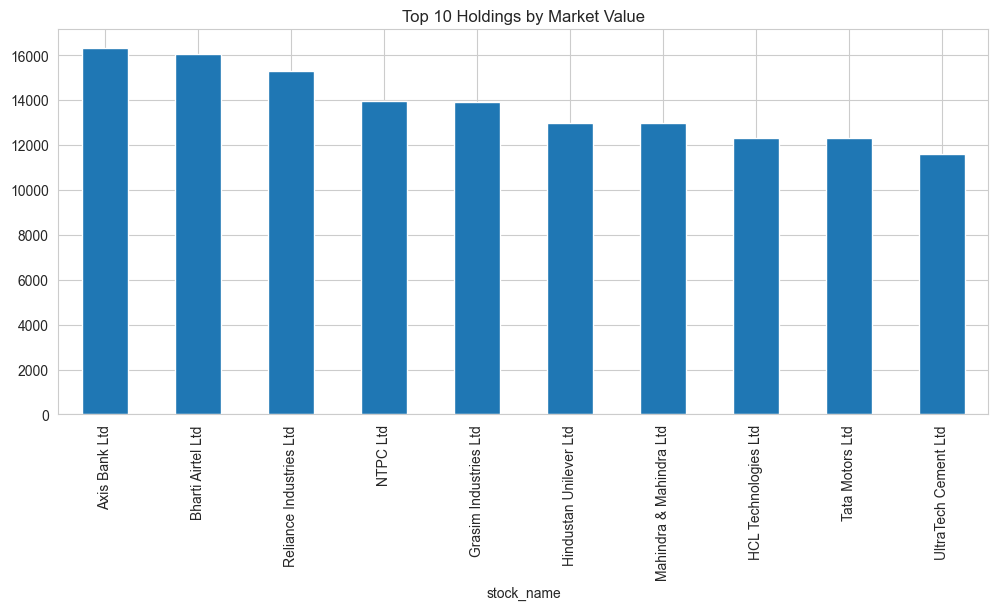

In [42]:
top_holdings = (
    portfolio.groupby('stock_name')['market_value_cr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_holdings.plot(kind='bar')

plt.title("Top 10 Holdings by Market Value")

plt.show()

### Insight 8

A small group of blue-chip stocks accounts for a significant portion of portfolio market value, indicating a preference for fundamentally strong and highly liquid companies.

## Chart 9: Fund Distribution by Category

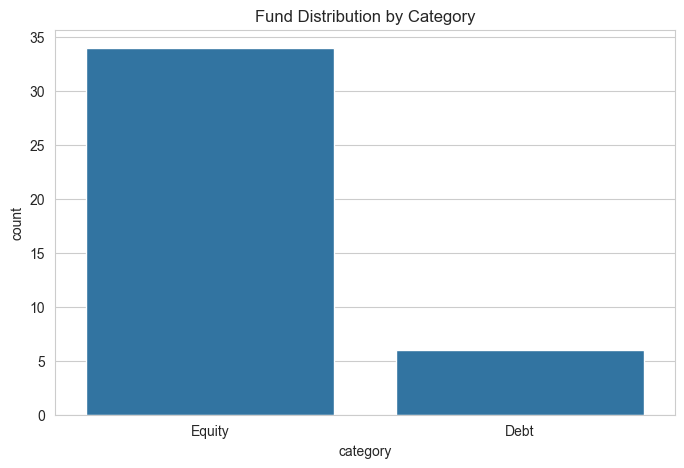

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=funds,
    x='category'
)

plt.title("Fund Distribution by Category")

plt.show()

### Insight 9

Equity funds constitute the majority of schemes in the dataset, demonstrating the growing investor preference for long-term wealth creation through equity investments.

## Chart 10: Risk Category Distribution

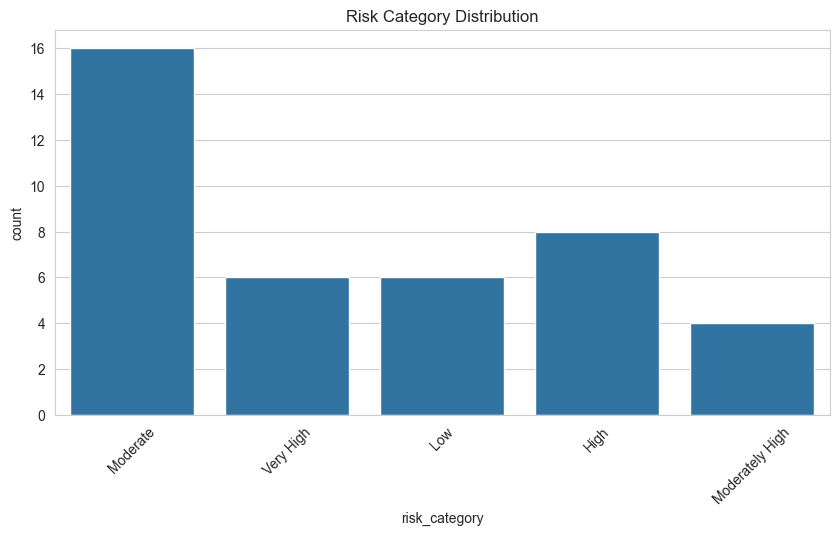

In [44]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=funds,
    x='risk_category'
)

plt.xticks(rotation=45)

plt.title("Risk Category Distribution")

plt.show()

### Insight 10

Most schemes are categorized under High or Very High risk levels, indicating that fund managers focus primarily on growth-oriented investment strategies.

In [45]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


## Chart 11: Top 10 Funds by 5-Year Return

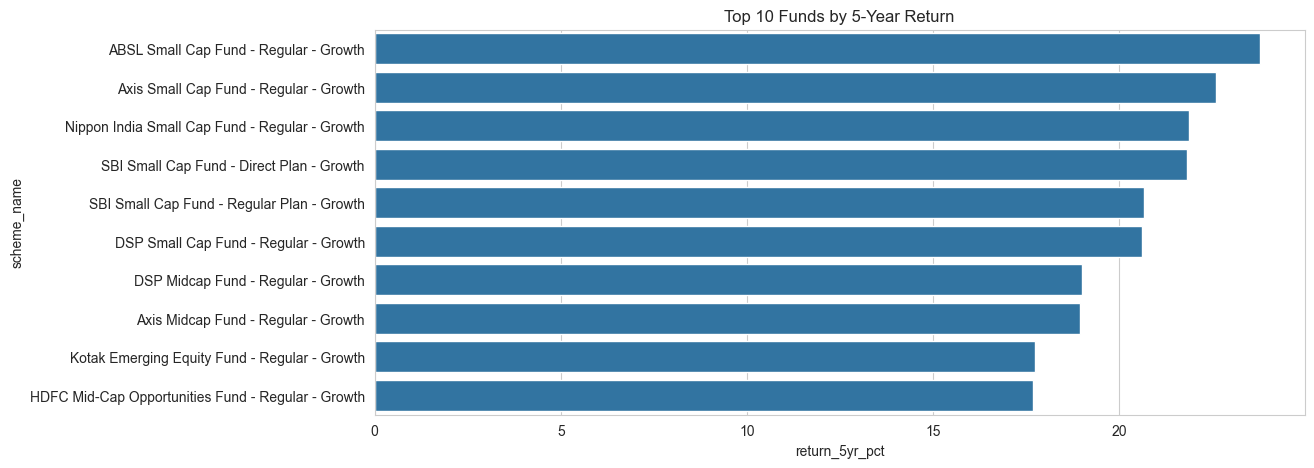

In [46]:
top_returns = (
    performance.sort_values(
        by='return_5yr_pct',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_returns,
    x='return_5yr_pct',
    y='scheme_name'
)

plt.title("Top 10 Funds by 5-Year Return")

plt.show()

### Insight 11

Small-cap and mid-cap funds dominate the top-performing schemes over the 5-year horizon.

## Chart 12: Return vs Risk Analysis

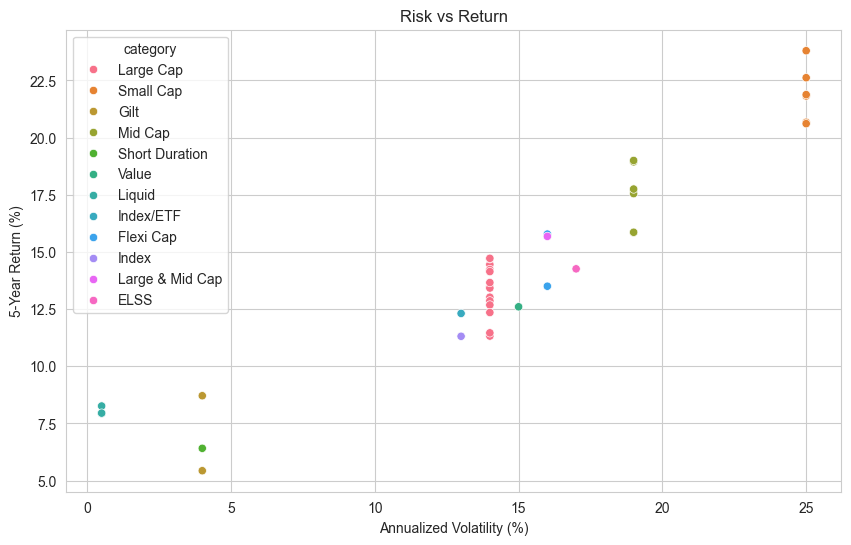

In [47]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x='std_dev_ann_pct',
    y='return_5yr_pct',
    hue='category'
)

plt.title("Risk vs Return")

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("5-Year Return (%)")

plt.show()

### Insight 12

Funds with higher long-term returns generally exhibit higher volatility, demonstrating the classic risk-return tradeoff.

## Chart 13: Sharpe Ratio Distribution

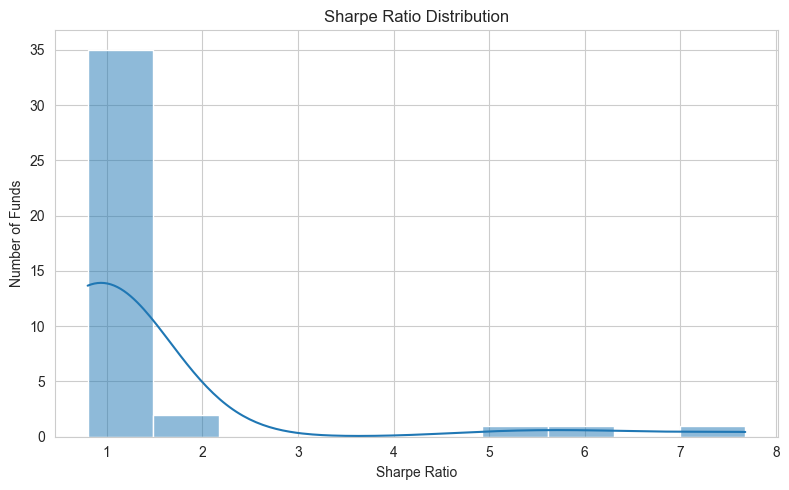

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance['sharpe_ratio'],
    bins=10,
    kde=True
)

plt.title("Sharpe Ratio Distribution")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.show()

### Insight 13

Most funds exhibit positive Sharpe ratios clustered around 1.0, indicating generally favorable risk-adjusted performance. A few funds show exceptionally high Sharpe ratios, suggesting superior risk-adjusted returns relative to peers.

## Chart 14: Morningstar Rating Distribution

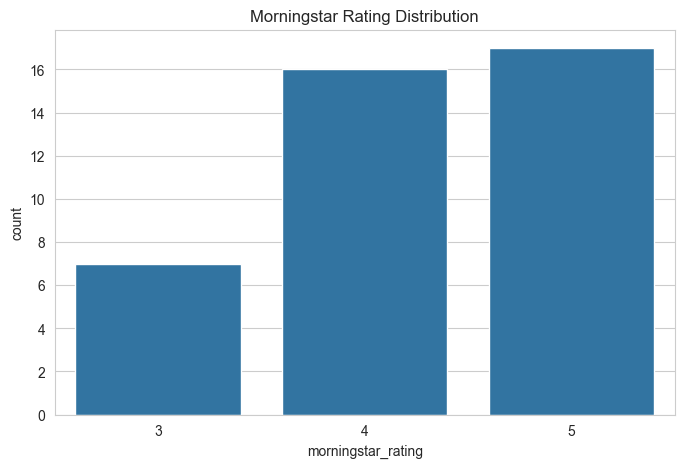

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x='morningstar_rating'
)

plt.title("Morningstar Rating Distribution")

plt.show()

### Insight 14

The majority of funds are rated between 3 and 5 stars, suggesting broadly competitive performance across schemes.

## Chart 15: Expense Ratio vs 5-Year Return

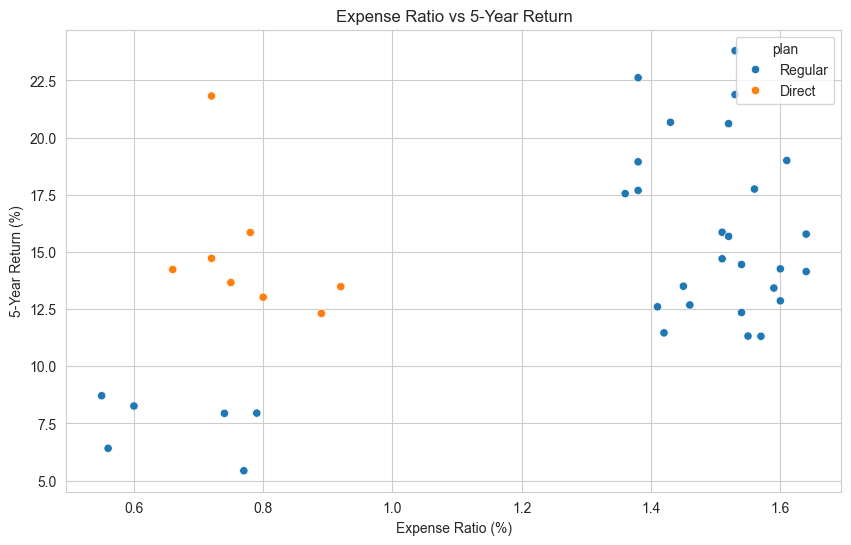

In [52]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x='expense_ratio_pct',
    y='return_5yr_pct',
    hue='plan'
)

plt.title("Expense Ratio vs 5-Year Return")

plt.xlabel("Expense Ratio (%)")
plt.ylabel("5-Year Return (%)")

plt.show()

### Insight 15

Lower expense ratios do not necessarily guarantee higher returns, highlighting the importance of portfolio management quality.

## Chart 16: NAV Return Correlation Matrix

In [55]:


top10_funds = nav_fund['scheme_name'].unique()[:10]

corr_df = nav_fund[
    nav_fund['scheme_name'].isin(top10_funds)
].copy()

print("Selected Funds:", len(top10_funds))

Selected Funds: 10


In [56]:


pivot_nav = corr_df.pivot(
    index='date',
    columns='scheme_name',
    values='nav'
)

pivot_nav.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,107.3758,26.3169,520.4608,42.8339,191.0721,119.2905,89.8728
2022-01-04,305.4514,310.6977,38.1545,105.9447,26.2234,515.0971,42.8033,189.0737,120.6402,90.8724
2022-01-05,306.6324,310.8165,38.1775,105.4800,26.2221,521.7239,43.0564,188.0701,121.4580,90.1565
2022-01-06,305.9800,310.7719,37.0665,104.9350,26.1728,515.7880,43.2088,190.4545,125.2386,91.5338
2022-01-07,304.0480,310.8388,37.9845,104.3318,26.2261,515.1639,42.9585,187.3124,124.1321,90.6762


In [57]:


daily_returns = pivot_nav.pct_change()

daily_returns.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.001153,-0.000141,-0.010865,-0.013328,-0.003553,-0.010306,-0.000714,-0.010459,0.011314,0.011122
2022-01-05,0.003866,0.000382,0.000603,-0.004386,-0.000050,0.012865,0.005913,-0.005308,0.006779,-0.007878
2022-01-06,-0.002128,-0.000143,-0.029101,-0.005167,-0.001880,-0.011377,0.003540,0.012678,0.031127,0.015277
2022-01-07,-0.006314,0.000215,0.024766,-0.005748,0.002036,-0.001210,-0.005793,-0.016498,-0.008835,-0.009369


In [58]:


corr_matrix = daily_returns.corr()

corr_matrix.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,-0.018079,0.023769,0.027747,-0.005432,-0.006490,0.007229,0.001570
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,0.007864,0.018455,-0.033773,0.003507,0.036547,0.014307,-0.001436
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.000351,-0.006710,0.016053,0.043384,0.002304,0.004860,-0.005929
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.018079,0.007864,0.000351,1.000000,0.002150,-0.000006,-0.013318,-0.036647,-0.018166,-0.034228
HDFC Short Term Debt Fund - Regular - Growth,0.023769,0.018455,-0.006710,0.002150,1.000000,0.045567,-0.014166,-0.005648,0.013754,-0.001038


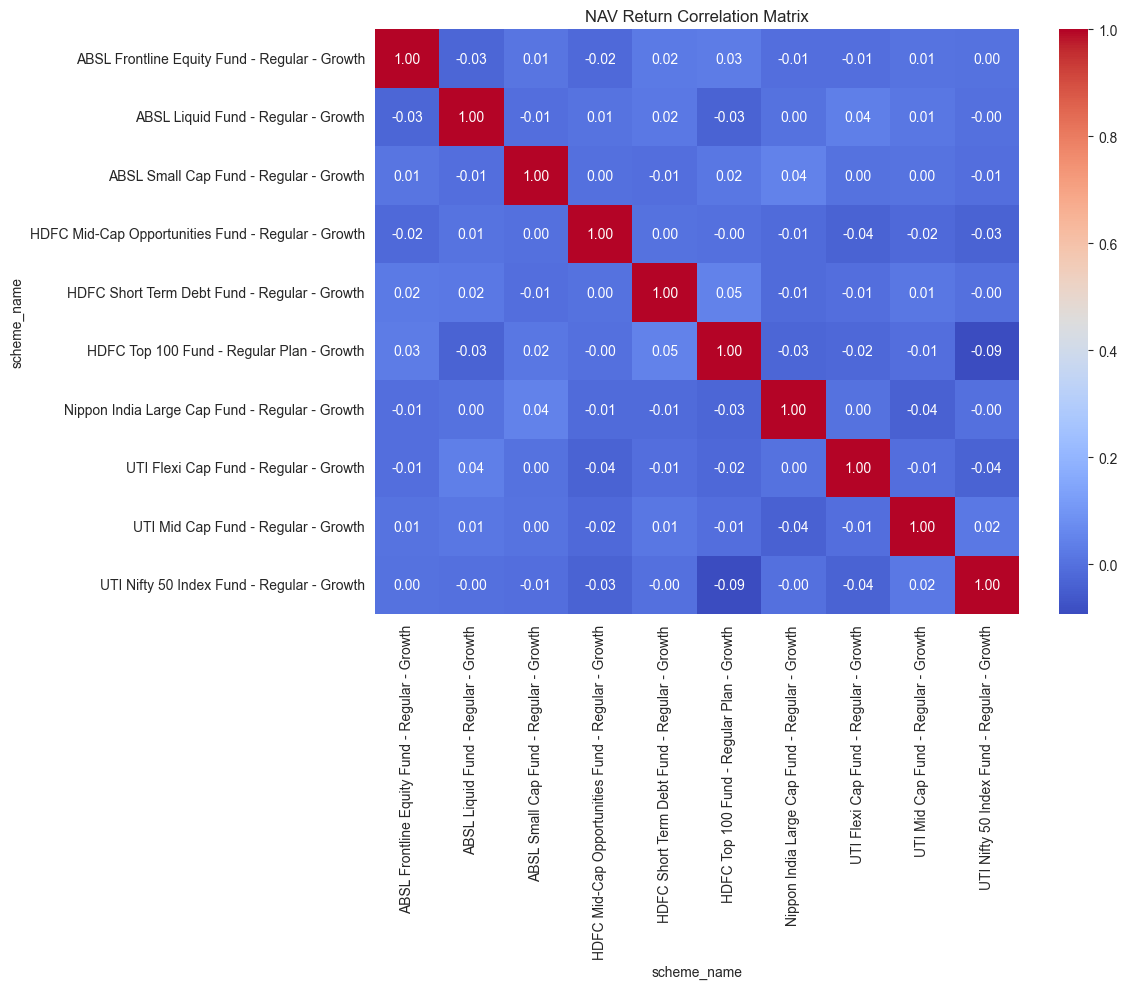

In [59]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.show()

### Insight 16

Funds belonging to similar categories exhibit stronger return correlations, whereas funds from different asset classes and investment styles provide better diversification benefits.